In [1]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
from sklearn.preprocessing import minmax_scale
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

Top-1 Accuracy: 41.67%
Top-2 Accuracy: 75.00%
Top-3 Accuracy: 83.33%
Top-4 Accuracy: 100.00%
Top-5 Accuracy: 100.00%


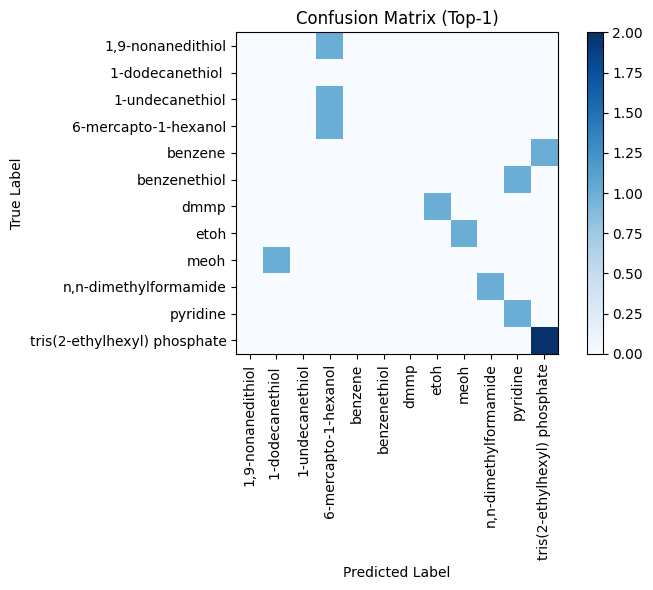

In [2]:
# 1. Load data
ref_df = pd.read_csv('Jesse_Dataset/reference.csv')
query_df = pd.read_csv('Jesse_Dataset/query.csv')

def baseline_als(y, lam=1e4, p=0.01, niter=10):
    L = len(y)
    D = np.diff(np.eye(L), 2)
    D = lam * D.dot(D.T)
    w = np.ones(L)
    for _ in range(niter):
        b = np.linalg.solve(np.diag(w) + D, w * y)
        w = p * (y > b) + (1 - p) * (y < b)
    return b

def preprocess(arr, lam=1e4, p=0.01, niter=10):
    out = np.zeros_like(arr)
    for i, spec in enumerate(arr):
        bkg = baseline_als(spec, lam=lam, p=p, niter=niter)
        corr = spec - bkg
        nrm = np.linalg.norm(corr)
        out[i] = corr / nrm if nrm else corr
    return out

def smooth(spec, K_smooth=3):
    window = np.ones(K_smooth) / K_smooth
    return np.convolve(spec, window, mode='same')

def build_CP_library(R, Q_len, K_smooth, height, prominence, N_peak, w_max):
    CPs = {}
    Ref_comp = {}
    for chem in np.unique(R[:, -1]):  # assume last column of R is label
        refs = R[R[:, -1] == chem, :-1]
        counts = np.zeros(Q_len, int)
        for spec in refs:
            pks, _ = find_peaks(smooth(spec, K_smooth), height=height, prominence=prominence)
            counts[pks] += 1
        cp_idxs = sorted(np.argsort(counts)[-N_peak:])
        CPs[chem] = cp_idxs

        comp = []
        hw = w_max // 2
        for spec in refs:
            vec = [np.max(spec[max(0, i - hw): i + hw + 1]) for i in cp_idxs]
            comp.append(minmax_scale(vec))
        Ref_comp[chem] = np.vstack(comp)
    return CPs, Ref_comp

def CaPSim(query_vector, reference_matrix):
    """
    Compute the mean dot‐product similarity between one query_vector and each row of reference_matrix.
    """
    return np.dot(reference_matrix, query_vector).mean()

# --- Main pipeline ---

def identify_spectrum_pipeline(query_df, ref_df,
    crop_max=1700, lam=1e4, p=0.01, niter=10,
    K_smooth=3, N_peak=12, w_max=15,
    height=0.01, prominence=None):

    # select wavenumber columns
    wav_cols = query_df.columns[:-1]
    wavs = pd.to_numeric(wav_cols)
    keep = wav_cols[wavs < crop_max]

    q = query_df[keep].values.astype(float)
    r = ref_df[keep].values.astype(float)
    r_lbl = ref_df['Label'].values

    # preprocess
    Q = preprocess(q, lam, p, niter)
    R = preprocess(r, lam, p, niter)

    # build CP library (we pass labels along as last column)
    R_with_lbl = np.hstack([R, r_lbl.reshape(-1, 1)])
    CPs, Ref_comp = build_CP_library(R_with_lbl, Q.shape[1],
                                     K_smooth, height, prominence,
                                     N_peak, w_max)

    # identification
    all_rankings = []
    for spec in Q:
        scores = {}
        hw = w_max // 2
        for chem, Rvs in Ref_comp.items():
            vec = [np.max(spec[max(0, i - hw): i + hw + 1]) for i in CPs[chem]]
            qv = minmax_scale(vec)
            scores[chem] = CaPSim(qv, Rvs)
        ranking = sorted(scores, key=scores.get, reverse=True)
        all_rankings.append(ranking)

    return all_rankings, Q, CPs, Ref_comp

# Run pipeline
rankings, Q, CPs, Ref_comp = identify_spectrum_pipeline(query_df, ref_df)

# Extract true labels and Top-k predictions
true_labels = query_df['Label'].values
preds_topk = np.array([[r[k] if k < len(r) else None for k in range(5)]
                       for r in rankings])

# Compute Top-1 through Top-5 accuracies
for k in range(1, 6):
    acc = np.mean([true in pred_row[:k]
                   for true, pred_row in zip(true_labels, preds_topk)])
    print(f"Top-{k} Accuracy: {acc:.2%}")

# Confusion matrix heatmap including all reference classes
all_labels = np.unique(np.concatenate((ref_df['Label'].values,
                                       true_labels)))
pred_top1 = preds_topk[:, 0]

cm = confusion_matrix(true_labels, pred_top1, labels=all_labels)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix (Top-1)")
plt.colorbar()
plt.xticks(np.arange(len(all_labels)), all_labels, rotation=90)
plt.yticks(np.arange(len(all_labels)), all_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()





[VAL] Top-1 Acc: 41.67%
[VAL] Top-2 Acc: 83.33%
[VAL] Top-3 Acc: 83.33%
[VAL] Top-4 Acc: 91.67%
[VAL] Top-5 Acc: 100.00%


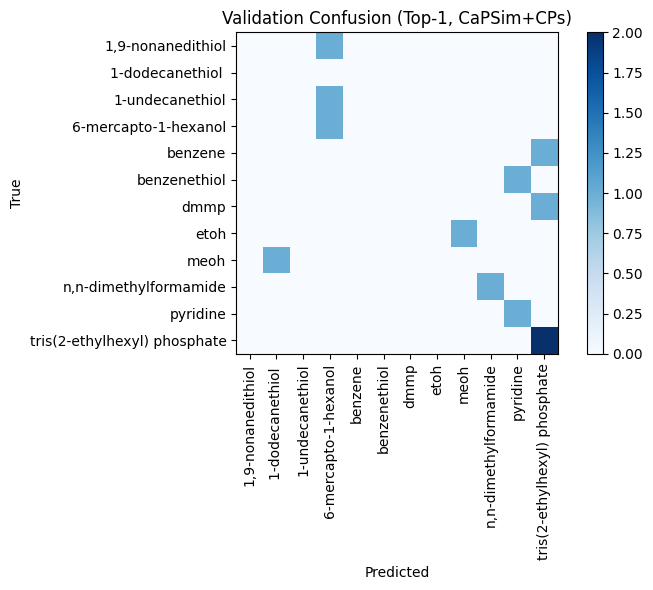

[TEST] Top-1 Acc: 30.04%
[TEST] Top-2 Acc: 85.16%
[TEST] Top-3 Acc: 85.16%
[TEST] Top-4 Acc: 96.47%
[TEST] Top-5 Acc: 100.00%


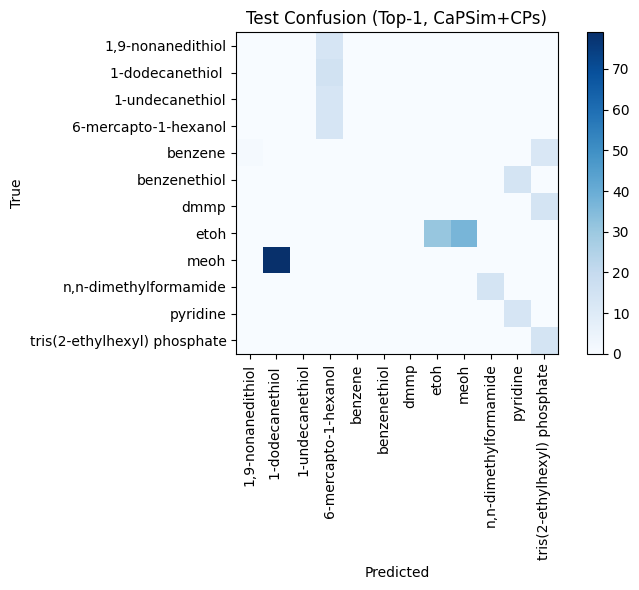

In [3]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
from sklearn.preprocessing import minmax_scale
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# ----------------------------
# Helpers (same behavior as before)
# ----------------------------
def baseline_als(y, lam=1e4, p=0.01, niter=10):
    L = len(y)
    D = np.diff(np.eye(L), 2)
    D = lam * D.dot(D.T)
    w = np.ones(L)
    for _ in range(niter):
        b = np.linalg.solve(np.diag(w) + D, w * y)
        w = p * (y > b) + (1 - p) * (y < b)
    return b

def preprocess(arr, lam=1e4, p=0.01, niter=10):
    out = np.zeros_like(arr, dtype=float)
    for i, spec in enumerate(arr):
        bkg = baseline_als(spec, lam=lam, p=p, niter=niter)
        corr = spec - bkg
        nrm = np.linalg.norm(corr)
        out[i] = corr / nrm if nrm else corr
    return out

def smooth(spec, K_smooth=3):
    window = np.ones(K_smooth) / K_smooth
    return np.convolve(spec, window, mode='same')

def build_CP_library(R_train, y_train, K_smooth=3, height=0.01, prominence=None,
                     N_peak=12, w_max=15):
    """
    Build characteristic-peak (CP) indices and per-class reference feature matrices
    from TRAINING spectra only.
    """
    classes = np.unique(y_train)
    n_feat = R_train.shape[1]
    CPs = {}
    Ref_comp = {}   # class -> (n_train_class x n_cp) feature matrix

    for chem in classes:
        refs = R_train[y_train == chem]
        counts = np.zeros(n_feat, dtype=int)
        for spec in refs:
            pks, _ = find_peaks(smooth(spec, K_smooth), height=height, prominence=prominence)
            counts[pks] += 1
        cp_idxs = np.argsort(counts)[-N_peak:]  # most frequent peaks
        cp_idxs = np.sort(cp_idxs)
        CPs[chem] = cp_idxs

        # build per-spectrum CP feature vectors (max in a ± w_max//2 window)
        hw = w_max // 2
        comp = []
        for spec in refs:
            vec = [np.max(spec[max(0, i - hw): i + hw + 1]) for i in cp_idxs]
            comp.append(minmax_scale(vec))
        Ref_comp[chem] = np.vstack(comp)

    return CPs, Ref_comp

def CaPSim(query_vector, reference_matrix):
    """Mean dot-product similarity between one query vector and each row of reference_matrix."""
    return np.dot(reference_matrix, query_vector).mean()

def rank_by_capsim(Q_proc, CPs, Ref_comp, w_max=15):
    """Return per-sample rankings using CaPSim with CP features."""
    hw = w_max // 2
    rankings = []
    classes = list(CPs.keys())
    for s in Q_proc:
        scores = {}
        for chem in classes:
            cp_idxs = CPs[chem]
            vec = [np.max(s[max(0, i - hw): i + hw + 1]) for i in cp_idxs]
            qv = minmax_scale(vec)
            scores[chem] = CaPSim(qv, Ref_comp[chem])
        ranking = sorted(scores, key=scores.get, reverse=True)
        rankings.append(ranking)
    return rankings

def topk_accuracy(true_labels, rankings, k=1):
    preds_topk = [[r[i] for i in range(min(k, len(r)))] for r in rankings]
    return np.mean([t in row for t, row in zip(true_labels, preds_topk)])

def plot_confusion(true_labels, pred_labels, labels, title, cmap='Blues'):
    cm = confusion_matrix(true_labels, pred_labels, labels=labels)
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    plt.xticks(np.arange(len(labels)), labels, rotation=90)
    plt.yticks(np.arange(len(labels)), labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

# ----------------------------
# Main: split -> train -> validate (query) -> test (hold-out)
# ----------------------------
ref_df = pd.read_csv('Jesse_Dataset/reference.csv')
query_df = pd.read_csv('Jesse_Dataset/query.csv')

# Common wavenumber columns and cropping
wav_cols = ref_df.columns[:-1]
wavs = pd.to_numeric(wav_cols, errors='coerce')
crop_max = 1700
keep = wav_cols[wavs < crop_max]

# Stratified split of reference library
ref_train, ref_test = train_test_split(
    ref_df, test_size=0.5, stratify=ref_df['Label'], random_state=42
)

# Build matrices
R_train_raw = ref_train[keep].values.astype(float)
y_train = ref_train['Label'].values
R_test_raw  = ref_test[keep].values.astype(float)
y_test = ref_test['Label'].values

Q_raw = query_df[keep].values.astype(float)
y_val = query_df['Label'].values

# Preprocess
lam, p, niter = 1e4, 0.01, 10
R_train = preprocess(R_train_raw, lam, p, niter)
R_test  = preprocess(R_test_raw,  lam, p, niter)
Q       = preprocess(Q_raw,       lam, p, niter)

# Build CP library from TRAIN only
K_smooth, N_peak, w_max = 3, 12, 15
height, prominence = 0.01, None
CPs, Ref_comp = build_CP_library(
    R_train, y_train, K_smooth=K_smooth, height=height,
    prominence=prominence, N_peak=N_peak, w_max=w_max
)

# ---- VALIDATION on query.csv ----
rank_val = rank_by_capsim(Q, CPs, Ref_comp, w_max=w_max)

for k in range(1, 6):
    print(f"[VAL] Top-{k} Acc: {topk_accuracy(y_val, rank_val, k=k):.2%}")

pred1_val = [r[0] if len(r) else None for r in rank_val]
labels_for_plots = np.unique(np.concatenate([y_train, y_val]))
plot_confusion(y_val, pred1_val, labels_for_plots, "Validation Confusion (Top-1, CaPSim+CPs)")

# ---- TEST on held-out reference split ----
rank_test = rank_by_capsim(R_test, CPs, Ref_comp, w_max=w_max)

for k in range(1, 6):
    print(f"[TEST] Top-{k} Acc: {topk_accuracy(y_test, rank_test, k=k):.2%}")

pred1_test = [r[0] if len(r) else None for r in rank_test]
labels_for_plots_test = np.unique(np.concatenate([y_train, y_test]))
plot_confusion(y_test, pred1_test, labels_for_plots_test, "Test Confusion (Top-1, CaPSim+CPs)")


In [4]:
# --- Class support summaries ---

def support_df(series, total=None, name="Support"):
    s = series.value_counts().sort_index()
    if total is None:
        total = int(s.sum())
    df = pd.DataFrame({ "Label": s.index, name: s.values })
    df[name + "_%"] = (df[name] / total * 100).round(2)
    return df

# Full reference dataset support
ref_support = support_df(ref_df['Label'], total=len(ref_df), name="Ref_Support")
print("\n[REFERENCE] Class support:")
print(ref_support.to_string(index=False))

# Query dataset support (optional, useful context)
qry_support = support_df(query_df['Label'], total=len(query_df), name="Query_Support")
print("\n[QUERY] Class support:")
print(qry_support.to_string(index=False))

# After you create y_train, y_test, also report split support:
train_support = support_df(pd.Series(y_train), total=len(y_train), name="Train_Support")
test_support  = support_df(pd.Series(y_test),  total=len(y_test),  name="Test_Support")

# Merge into one table over all labels seen anywhere
labels_all = sorted(set(ref_df['Label']) | set(query_df['Label']))
summary = pd.DataFrame({"Label": labels_all})
for part in [ref_support, train_support, test_support, qry_support]:
    summary = summary.merge(part, on="Label", how="left")

# Fill missing with zeros and tidy types
for col in summary.columns:
    if col.endswith("Support"):
        summary[col] = summary[col].fillna(0).astype(int)
    if col.endswith("%"):
        summary[col] = summary[col].fillna(0.0)

print("\n[SUMMARY] Support per class (reference / train / test / query):")
print(summary.to_string(index=False))

# (Optional) Save to CSVs
ref_support.to_csv("class_support_reference.csv", index=False)
summary.to_csv("class_support_summary_ref_train_test_query.csv", index=False)



[REFERENCE] Class support:
                       Label  Ref_Support  Ref_Support_%
           1,9-nonanedithiol           27           4.78
            1-dodecanethiol            30           5.31
             1-undecanethiol           26           4.60
        6-mercapto-1-hexanol           27           4.78
                     benzene           27           4.78
                benzenethiol           27           4.78
                        dmmp           27           4.78
                        etoh          135          23.89
                        meoh          157          27.79
       n,n-dimethylformamide           28           4.96
                    pyridine           27           4.78
tris(2-ethylhexyl) phosphate           27           4.78

[QUERY] Class support:
                       Label  Query_Support  Query_Support_%
           1,9-nonanedithiol              1             8.33
             1-undecanethiol              1             8.33
        6-mercapto-1-hex